# Function 3

<b> Description of the Sample Application:</b> You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine.
Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array.
Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects). 



In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# Load and Analyse the Data

In [10]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X       = np.load(input_file)
y       = np.load(output_file)

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", y.shape)
print("Outputs:\n", y)
print()

print(f"y Range: [: {y.min()}, {y.max()}]")
best_idx   = np.argmax(y)
print(f"Best point: x = {X[best_idx]}, y = {y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['y'] = y
print("Data Frame:\n", df)


Input  Shape: (15, 3)
Inputs:
 [[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.94135983 0.26936348]
 [0.15183663 0.43999062 0.99088187]
 [0.64550284 0.39714294 0.91977134]
 [0.74691195 0.28419631 0.22629985]
 [0.17047699 0.6970324  0.14916943]
 [0.22054934 0.29782524 0.34355534]
 [0.66601366 0.67198515 0.2462953 ]
 [0.04680895 0.23136024 0.77061759]
 [0.60009728 0.72513573 0.06608864]
 [0.96599485 0.86111969 0.56682913]]

Output Shape: (15,)
Outputs:
 [-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741 -0.10596504
 -0.11804826 -0.03637783 -0.05675837]

y Range: [: -0.3989255131463011, -0.034835313350078584]
Best point: x = [0.49258141 0.61159319 0.34017639], y = -0.034835313350078584

Data Frame:
          X_1       X_2       X_3         y
0   0.171525  0.34391

# Data Exploration

In [14]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3          y
count  15.000000  15.000000  15.000000  15.000000
mean    0.409031   0.517677   0.402788  -0.107167
std     0.275039   0.232950   0.284142   0.087170
min     0.046809   0.219917   0.066089  -0.398926
25%     0.171001   0.320871   0.236298  -0.112995
50%     0.345523   0.439991   0.272433  -0.105965
75%     0.622800   0.684509   0.512518  -0.052383
max     0.965995   0.941360   0.990882  -0.034835


In [16]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
y      0
dtype: int64


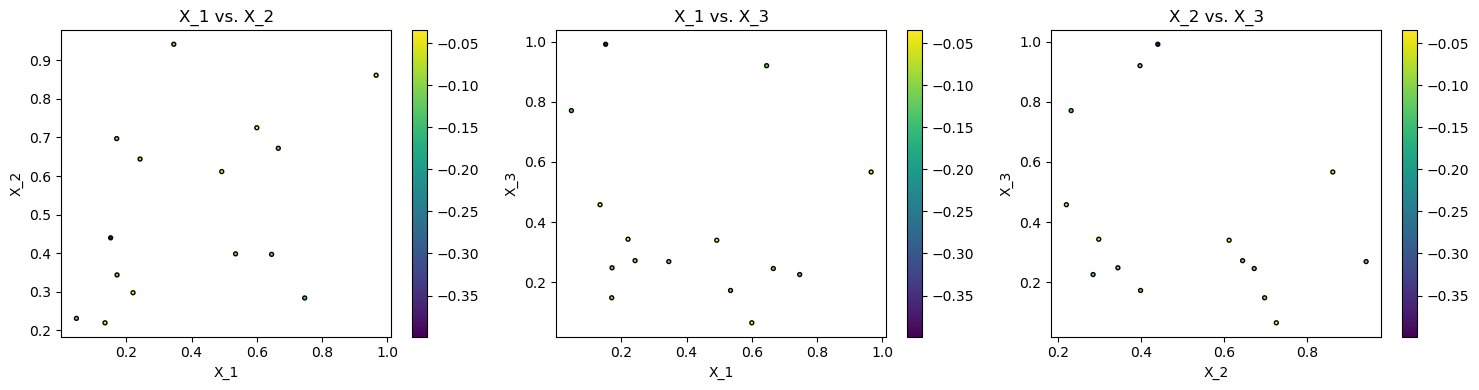

In [18]:
# Pairwise Scatter Plot
labels      = ["X_1", "X_2", "X_3"]
fig, axes   = plt.subplots(1, 3, figsize = (15, 4))
pairs       = [(0, 1), (0, 2), (1, 2)]
for ax, (i, j) in zip(axes, pairs):
    sc      = ax.scatter(X[:, i], X[:, j], c = y, cmap = "viridis", s = 8, edgecolor = "k")
    ax.set_xlabel(labels[i])
    ax.set_ylabel(labels[j])
    ax.set_title(f"{labels[i]} vs. {labels[j]}")
    plt.colorbar(sc, ax = ax)
plt.tight_layout()

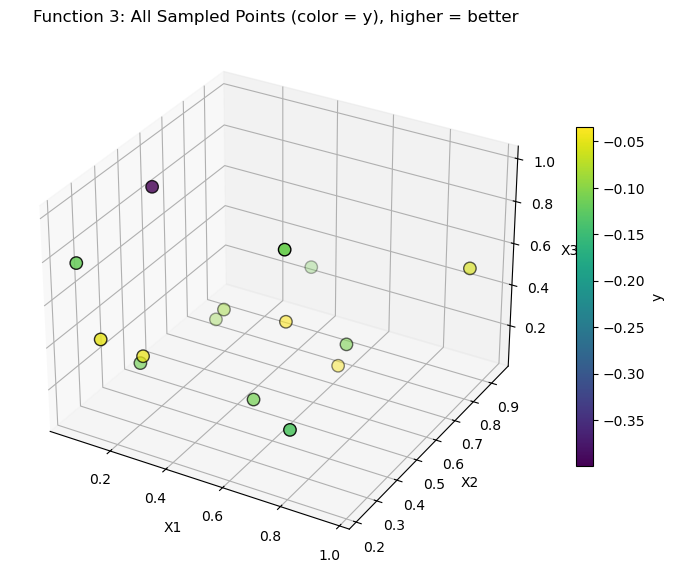

In [20]:
# 3D Scatter Plot
fig       = plt.figure(figsize = (7,6))
ax        = fig.add_subplot(111, projection = "3d")
sc        = ax.scatter(X[:,0], X[:,1], X[:, 2], c = y, cmap = "viridis", s = 80, edgecolor = "k")
    
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("X3")
ax.set_title('Function 3: All Sampled Points (color = y), higher = better')
fig.colorbar(sc, shrink = 0.6, label = "y")
plt.tight_layout()
plt.show()

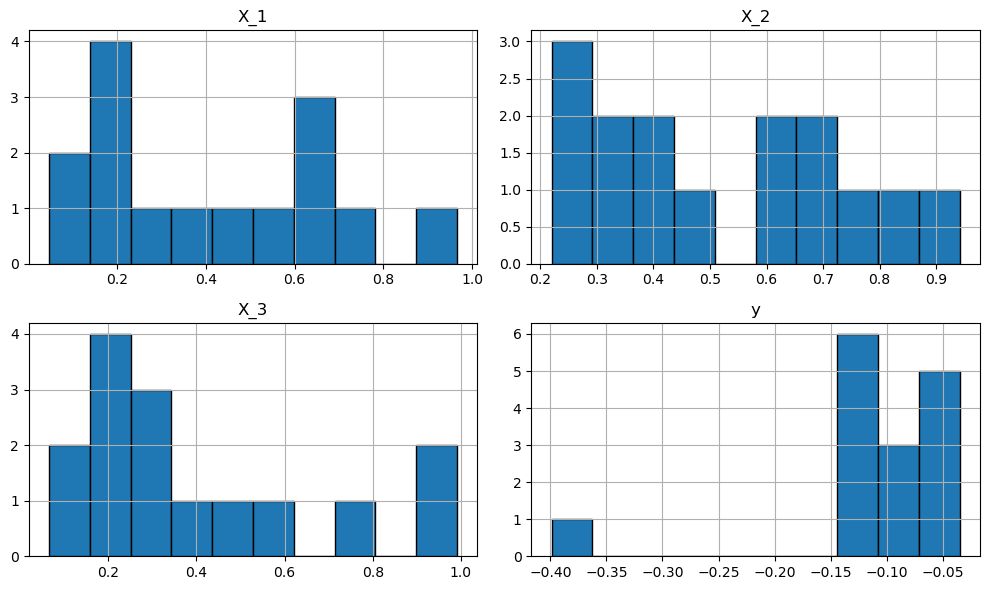

In [22]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [24]:
# Understanding Correlation between each drug 
print("Correlation of each drug with y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], y)[0, 1]
    print(f" corr({lab}, y) = {corr}")

Correlation of each drug with y:

 corr(X_1, y) = 0.25060654296364515
 corr(X_2, y) = 0.15843860618924063
 corr(X_3, y) = -0.573676115510642


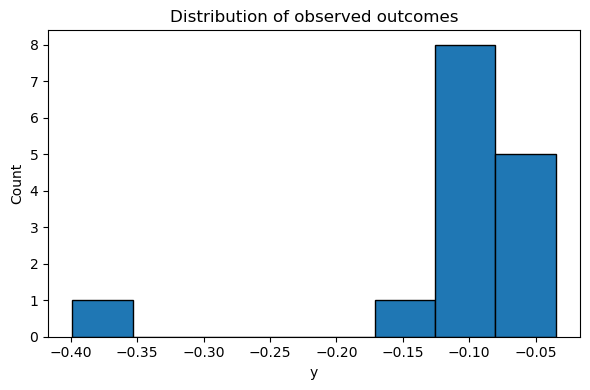

In [26]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
plt.hist(y, bins = 8, edgecolor = "k")
plt.xlabel("y")
plt.ylabel("Count")
plt.title("Distribution of observed outcomes")
plt.tight_layout()

# Initialize Gaussian Process

In [29]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 10)) \
                + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-2, 1e-1))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = True, n_restarts_optimizer = 10, random_state = 0 )

# Fit the Gaussian Processes to existing data

In [32]:
# Train the model

gpr.fit(X, y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  1.5**2 * RBF(length_scale=[10, 10, 0.0806]) + WhiteKernel(noise_level=0.014)


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [36]:
n_candidates = 50000
candidates   = np.random.uniform(0, 1, size = (n_candidates, 3))

mu, std      = gpr.predict(candidates, return_std = True)

# Setting a higher beta(= 2.5) for Week -1
beta         = 2.5
ucb          = mu + beta * std

best_ucb_idx   = np.argmax(ucb)
next_point     = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"Predicted Mean(μ): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (σ): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.98973577 0.93759164 0.84960875]
Predicted Mean(μ): -1.284797e-02
Predicted Std (σ): 5.959945e-02
UCB Score: 1.361507e-01


# Perform Visualisation

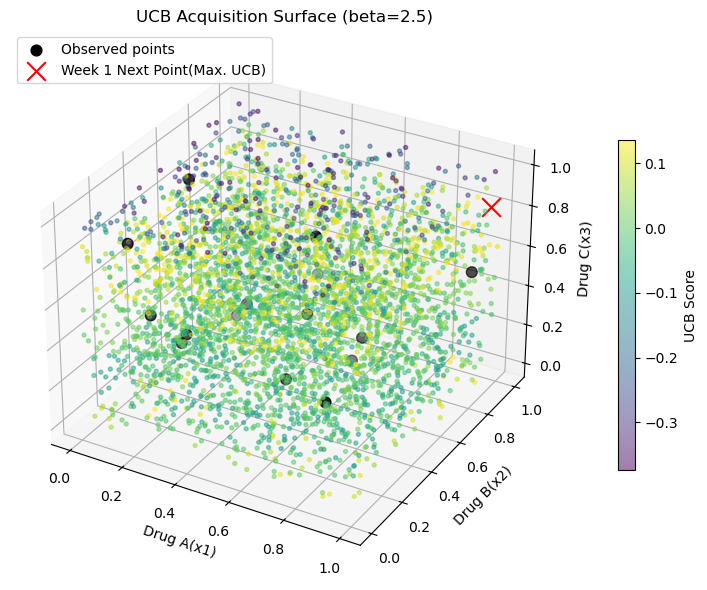

In [39]:
plot_n     = 4000
idx_sample = np.random.choice(n_candidates, size = plot_n, replace = False)
fig        = plt.figure(figsize = (12, 6))
ax         = fig.add_subplot(111, projection = "3d")
sc         = ax.scatter(candidates[idx_sample, 0],
                        candidates[idx_sample, 1],
                        candidates[idx_sample, 2],
                        c = ucb[idx_sample], cmap = "viridis", s = 8, alpha = 0.5
                       )


ax.scatter(X[:, 0], X[:, 1], X[:, 2], c = "black", s = 60, marker = "o", label="Observed points")
ax.scatter(*next_point, c = "red", s = 180, marker = "x", label="Week 1 Next Point(Max. UCB)")
ax.set_xlabel("Drug A(x1)")
ax.set_ylabel("Drug B(x2)")
ax.set_zlabel("Drug C(x3)")
ax.set_title("UCB Acquisition Surface (beta=2.5)")
fig.colorbar(sc, shrink = 0.6, label = "UCB Score")
ax.legend(loc = "upper left")
plt.tight_layout()
plt.show()

# Portal Submission 

In [42]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
submission_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}"
print("Points to be submitted(Week 1):", submission_str)
print()

Points to be submitted(Week 1): 0.989736-0.937592-0.849609

